In [28]:
import pandas as pd
import numpy as np

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [29]:
# Model Saving
import joblib

In [2]:
df_crop = pd.read_csv("C:\\Users\\ayush\\Desktop\\College\\5th sem\\Advance ML\\Smart Crop\\Crop_recommendation.csv")

In [3]:
df_crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df_crop.shape

(2200, 8)

In [5]:
df_crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   N                     2200 non-null   int64  
 1    P                    2200 non-null   int64  
 2    K                    2200 non-null   int64  
 3    temperature          2200 non-null   float64
 4    humidity             2200 non-null   float64
 5    ph                   2200 non-null   float64
 6    rainfall             2200 non-null   float64
 7    label                2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   N                     2200 non-null   int64  
 1    P                    2200 non-null   int64  
 2    K                    2200 non-null   int64  
 3    temperature          2200 non-null   float64
 4    humidity             2200 non-null   float64
 5    ph                   2200 non-null   float64
 6    rainfall             2200 non-null   float64
 7    label                2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
df_crop.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [7]:
df_crop.isnull().sum()

N                       0
 P                      0
 K                      0
 temperature            0
 humidity               0
 ph                     0
 rainfall               0
 label                  0
dtype: int64

In [10]:
df_crop.duplicated().sum()

np.int64(0)

In [11]:
print(df_crop.columns.tolist())

['N  ', ' P  ', ' K  ', ' temperature       ', ' humidity          ', ' ph                ', ' rainfall           ', ' label']


In [15]:
df_crop.columns = df_crop.columns.str.strip()

print(df_crop.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [16]:
print(df_crop["label"].unique())

[' rice' ' maize' ' chickpea' ' kidneybeans' ' pigeonpeas' ' mothbeans'
 ' mungbean' ' blackgram' ' lentil' ' pomegranate' ' banana' ' mango'
 ' grapes' ' watermelon' ' muskmelon' ' apple' ' orange' ' papaya'
 ' coconut' ' cotton' ' jute' ' coffee']


In [17]:
df_crop["label"] = df_crop["label"].str.strip()

In [18]:
print(df_crop["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


## Data Visualization

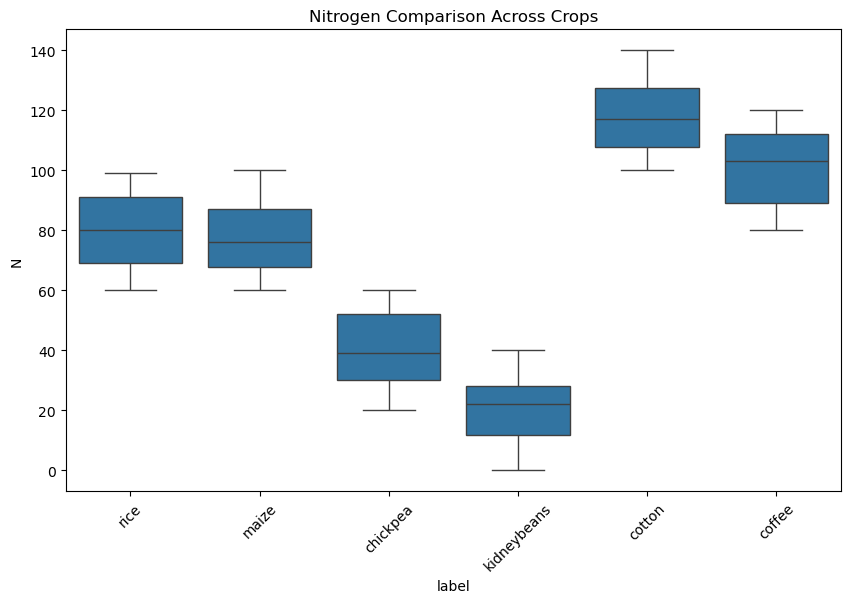

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

crops = ["rice", "maize", "chickpea", "kidneybeans", "coffee", "cotton"]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_crop[df_crop["label"].isin(crops)],
    x="label",
    y="N"
)

plt.xticks(rotation=45)
plt.title("Nitrogen Comparison Across Crops")
plt.show()

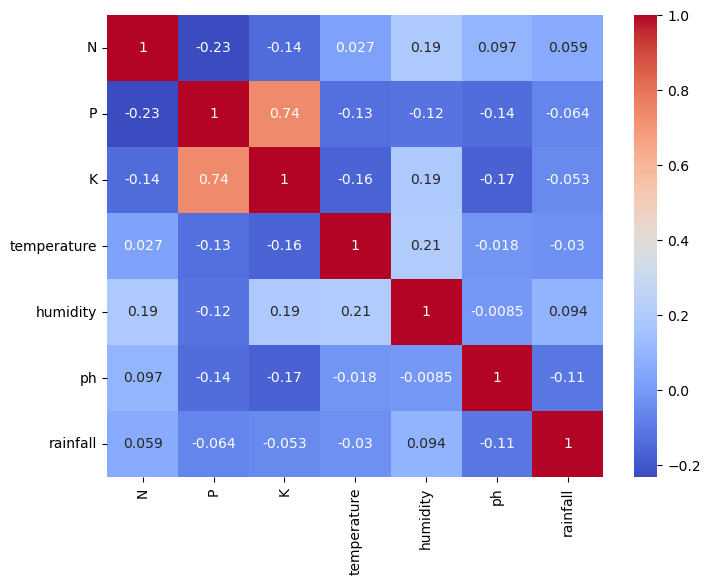

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_crop.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

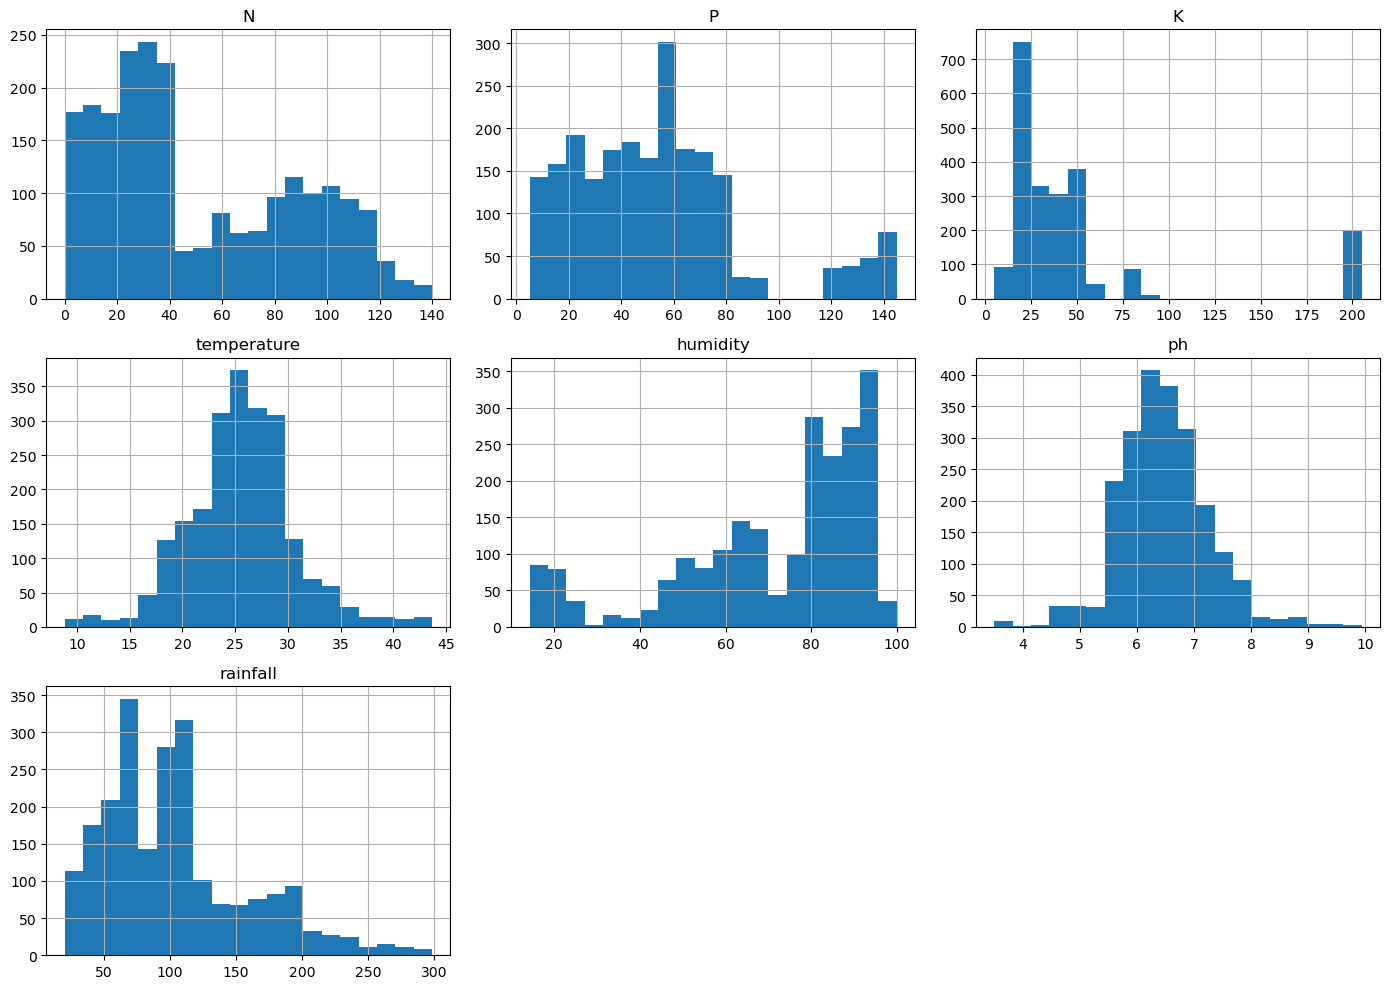

In [22]:
features = ["N","P","K","temperature","humidity","ph","rainfall"]

df_crop[features].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

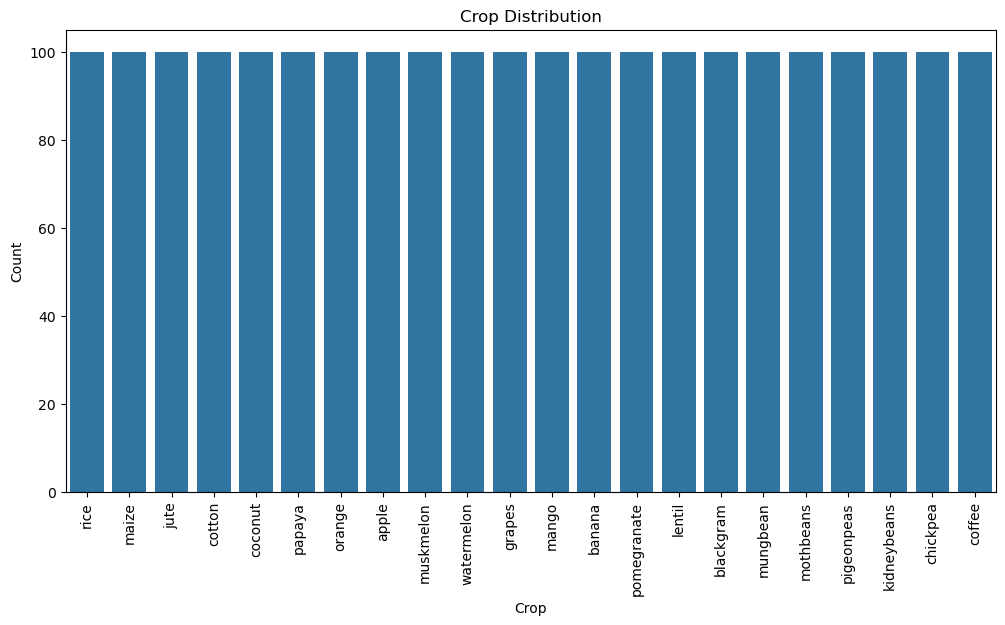

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_crop,
    x="label",
    order=df_crop["label"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Crop Distribution")

plt.xlabel("Crop")

plt.ylabel("Count")

plt.show()

## Encode Target Column

In [30]:
label_encoder = LabelEncoder()

# Create a new encoded column
df_crop["label_encoded"] = label_encoder.fit_transform(df_crop["label"])

In [32]:
df_crop[["label", "label_encoded"]].head(10)

,label,label_encoded
0,rice,20
1,rice,20
2,rice,20
3,rice,20
4,rice,20
5,rice,20
6,rice,20
7,rice,20
8,rice,20
9,rice,20


In [33]:
mapping = pd.DataFrame({
    "Crop": label_encoder.classes_,
    "Encoded Value": range(len(label_encoder.classes_))
})

mapping

,Crop,Encoded Value
0,apple,0
1,banana,1
2,blackgram,2
3,chickpea,3
4,coconut,4
5,coffee,5
6,cotton,6
7,grapes,7
8,jute,8
9,kidneybeans,9


## Feature Selection

In [34]:
X = df_crop.drop(columns=["label", "label_encoded"])
y = df_crop["label_encoded"]

In [35]:
print(X.head())
print(y.head())

    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340
0    20
1    20
2    20
3    20
4    20
Name: label_encoded, dtype: int64


## Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1760, 7)
Testing Features  : (440, 7)
Training Labels   : (1760,)
Testing Labels    : (440,)


## Decision Tree Classifier

In [38]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_pred_dt = dt_model.predict(X_test)

In [40]:
print(y_pred_dt[:10])

[16  1  6 11 16  3 20  2  1 16]


In [41]:
predicted_crops = label_encoder.inverse_transform(y_pred_dt)

print(predicted_crops[:10])

['orange' 'banana' 'cotton' 'maize' 'orange' 'chickpea' 'rice' 'blackgram'
 'banana' 'orange']


In [42]:
# Evaluation Metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9795454545454545
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00     

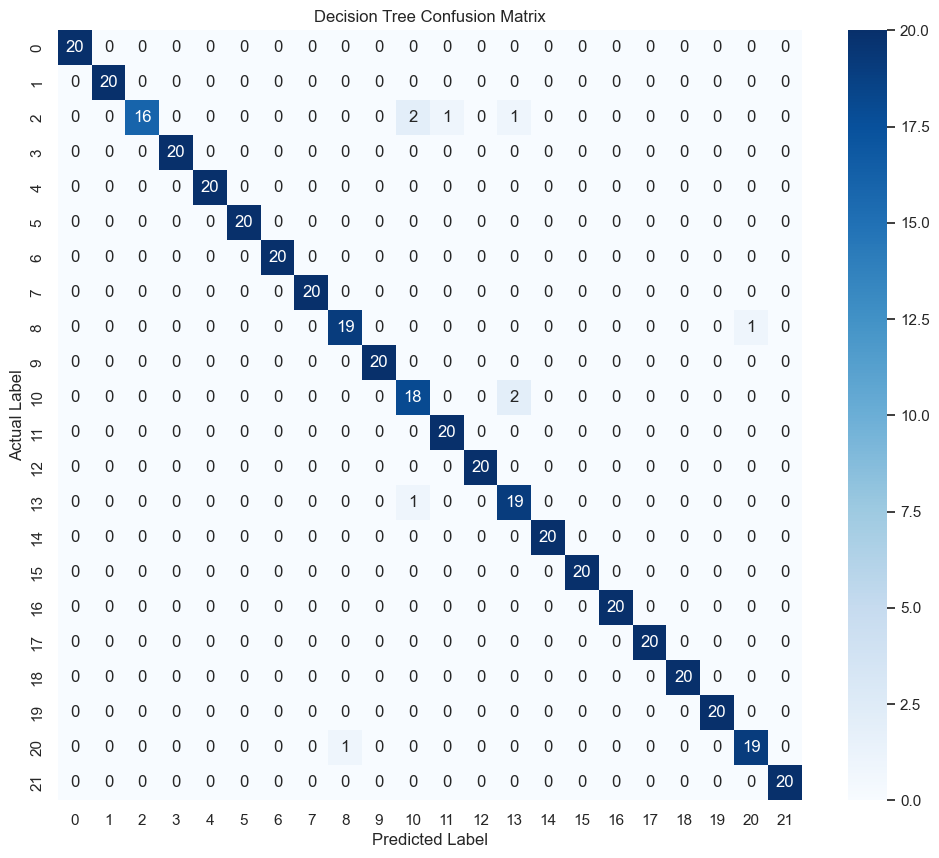

In [43]:
# Visualize the Confusion Matrix

plt.figure(figsize=(12,10))

sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Random Forest

In [44]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred_rf = rf_model.predict(X_test)

In [46]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.9955


In [47]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

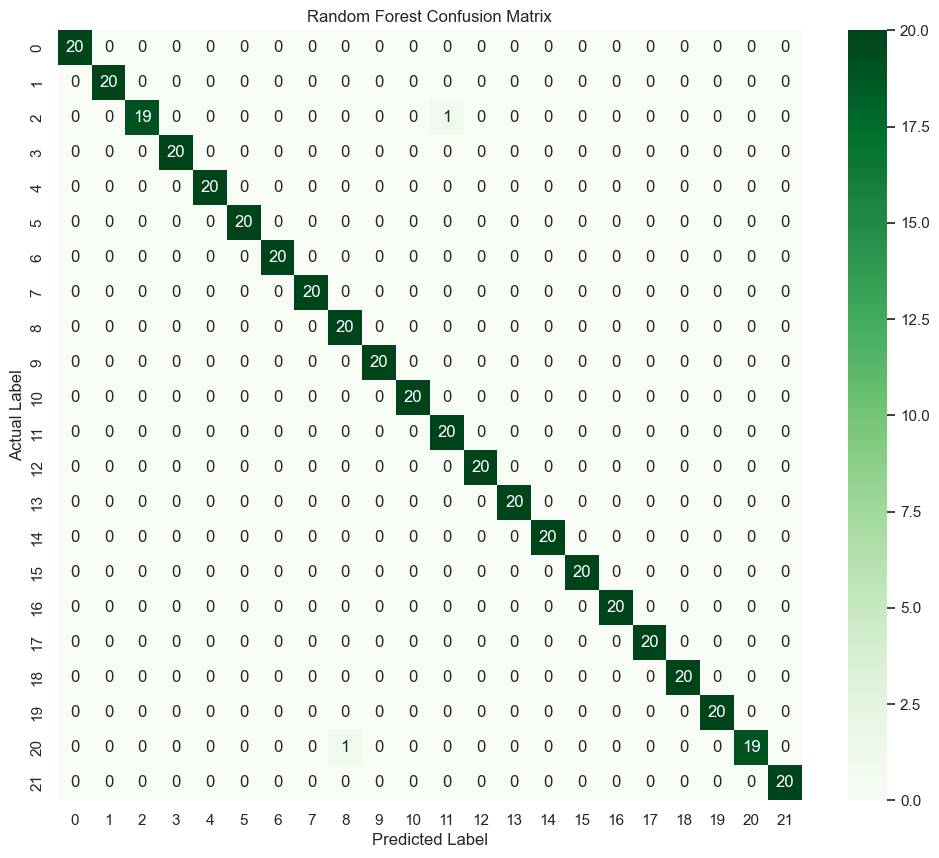

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Compare Both Models

In [49]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.979545
1,Random Forest,0.995455


# feature importance

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,rainfall,0.230184
4,humidity,0.224227
2,K,0.175393
1,P,0.150850
0,N,0.096363
3,temperature,0.072375
5,ph,0.050608


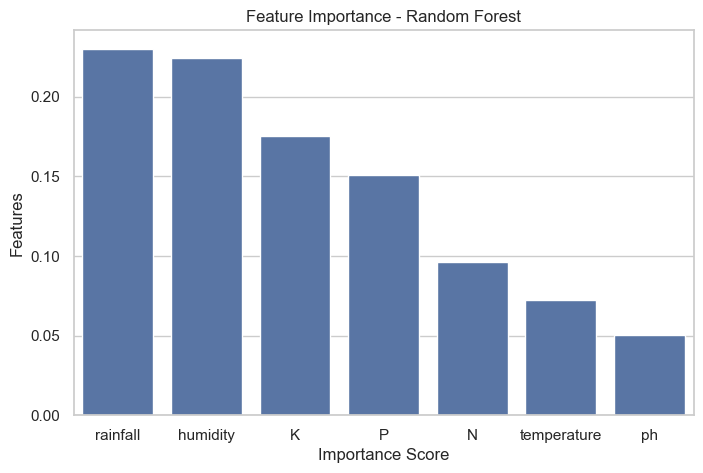

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    y="Importance",
    x="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## recommend_crop() Function

In [52]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall):
    

    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    
    prediction = rf_model.predict(input_data)

    
    crop = label_encoder.inverse_transform(prediction)

    return crop[0]

In [53]:
# Test

recommend_crop(
    N=90,
    P=42,
    K=43,
    temperature=20.8,
    humidity=82.0,
    ph=6.5,
    rainfall=202.9
)

'rice'

In [54]:
# save the model and label encoder

import joblib

joblib.dump(rf_model, "crop_recommendation_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']